In [211]:
# Базовые
import pandas as pd
import numpy as np
from collections import Counter

# Предобработка
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SMOTE
from imblearn.over_sampling import SMOTE

# Модель
from sklearn.ensemble import RandomForestClassifier

# Визуализация
import matplotlib.pyplot as plt

In [193]:

df = pd.read_csv('/Users/zentrovoy/Documents/BOOTCAMP/TEST/loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [214]:
np.array

<function numpy.array>

In [194]:

df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [195]:
df.isnull().sum() / len(df) * 100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [196]:
df = df.dropna(subset=['Gender','Married','Dependents','Self_Employed'])
df.drop('Loan_ID', axis=1, inplace=True)

In [197]:
# df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

# df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

In [198]:
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})
df['Married'] = df['Married'].map({'Yes':1,'No':0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1,'No':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1,'N':0})


In [199]:
df = pd.get_dummies(df, columns=['Property_Area'])
df = pd.get_dummies(df, columns=['Dependents'])

In [200]:
df


,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Dependents_0,Dependents_1,Dependents_2,Dependents_3+
0,1,0,1,0,5849,0.0,127.0,360.0,1.0,1,False,False,True,True,False,False,False
1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False,False,True,False,False
2,1,1,1,1,3000,0.0,66.0,360.0,1.0,1,False,False,True,True,False,False,False
3,1,1,0,0,2583,2358.0,120.0,360.0,1.0,1,False,False,True,True,False,False,False
4,1,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,1,0,2900,0.0,71.0,360.0,1.0,1,True,False,False,True,False,False,False
610,1,1,1,0,4106,0.0,40.0,180.0,1.0,1,True,False,False,False,False,False,True
611,1,1,1,0,8072,240.0,253.0,360.0,1.0,1,False,False,True,False,True,False,False
612,1,1,1,0,7583,0.0,187.0,360.0,1.0,1,False,False,True,False,False,True,False


In [201]:
import matplotlib as plt

df['Loan_Status'].value_counts()


Loan_Status
1    382
0    172
Name: count, dtype: int64

In [202]:
# 1. Делим данные
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

# 2. Сохраняем названия признаков
feature_names = X.columns.tolist()

# 3. Масштабируем
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Before SMOTE: {Counter(y_train)}")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print(f"After SMOTE: {Counter(y_resampled)}")

# 5. Преобразуем обратно в DataFrame
X_resampled = pd.DataFrame(X_resampled, columns=feature_names)

Before SMOTE: Counter({1: 256, 0: 115})
After SMOTE: Counter({1: 256, 0: 256})


🔝 Top 3 important features:
             Feature  Importance
8     Credit_History    0.212576
6         LoanAmount    0.162429
4    ApplicantIncome    0.161714
5  CoapplicantIncome    0.098615
7   Loan_Amount_Term    0.058198


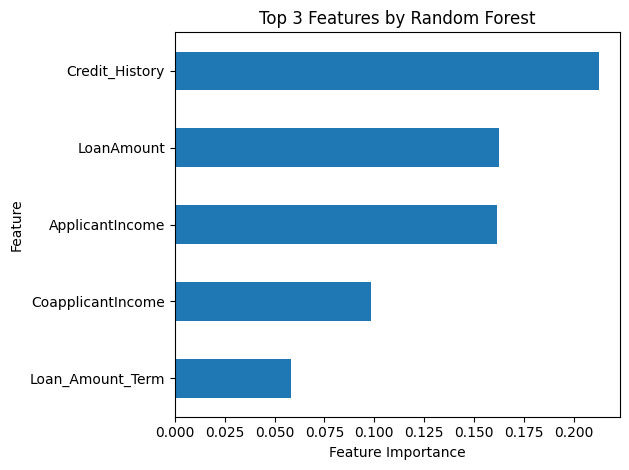

In [203]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# Преобразуем X_resampled обратно в DataFrame
X_resampled = pd.DataFrame(X_resampled, columns=feature_names)

# Обучаем Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_resampled, y_resampled)

# Извлекаем важности признаков
importances = model.feature_importances_
feature_names = X.columns.tolist()
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Сортировка по важности
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Топ-3 признака
top3 = feature_importance_df.head(5)
print("🔝 Top 3 important features:")
print(top3)

# Визуализация
top3.plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.xlabel("Feature Importance")
plt.title("Top 3 Features by Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


=== Logistic Regression ===
Accuracy:  0.727
Precision: 0.797
Recall:    0.810
F1-score:  0.803
AUC-ROC:   0.750
Confusion Matrix:
[[ 31  26]
 [ 24 102]]

=== Random Forest ===
Accuracy:  0.765
Precision: 0.807
Recall:    0.865
F1-score:  0.835
AUC-ROC:   0.752
Confusion Matrix:
[[ 31  26]
 [ 17 109]]

=== XGBoost ===
Accuracy:  0.727
Precision: 0.806
Recall:    0.794
F1-score:  0.800
AUC-ROC:   0.738
Confusion Matrix:
[[ 33  24]
 [ 26 100]]

=== Summary Table ===


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.726776,0.796875,0.809524,0.803150,0.749652
1,Random Forest,0.765027,0.807407,0.865079,0.835249,0.751532
2,XGBoost,0.726776,0.806452,0.793651,0.800000,0.737678


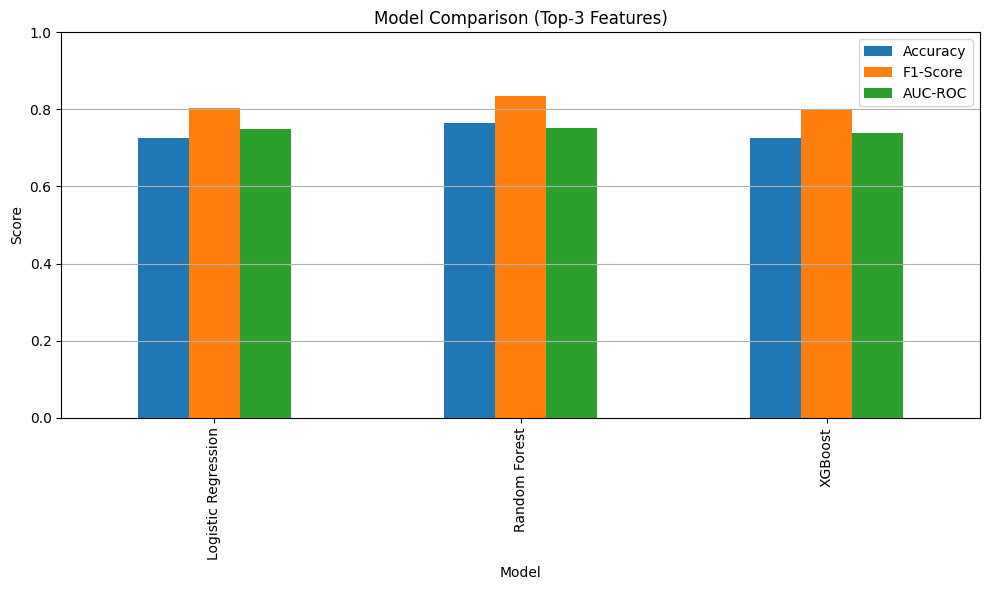

In [204]:
import pandas as pd
import numpy as np
import warnings
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# 🔇 Убираем предупреждения
warnings.filterwarnings('ignore')

# 📌 Обучающие данные уже подготовлены:
X_train = X_resampled
y_train = y_resampled

# 📌 Модели
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 📊 Сбор результатов
results = []

# 📌 Оценка каждой модели
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # 👉 Метрики
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # 🔢 Вывод в консоль — короткий
    print(f"\n=== {name} ===")
    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"AUC-ROC:   {auc:.3f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # 🧾 Полный отчёт можно отдельно — если нужно
    # print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))

    # 📥 Добавляем в итоговую таблицу
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc
    })

# 🧾 Показываем финальную таблицу
results_df = pd.DataFrame(results)
print("\n=== Summary Table ===")
display(results_df)

# 📈 (опционально) Построим bar chart по F1-score
results_df.plot(x='Model', y=['Accuracy', 'F1-Score', 'AUC-ROC'], kind='bar', figsize=(10, 6))
plt.title("Model Comparison (Top-3 Features)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

[[ 33  24]
 [ 26 100]]


<Axes: >

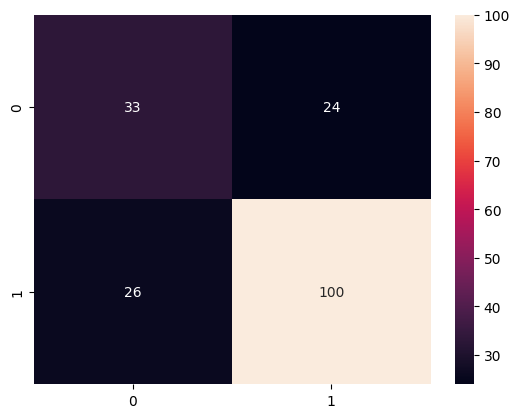

In [208]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d')

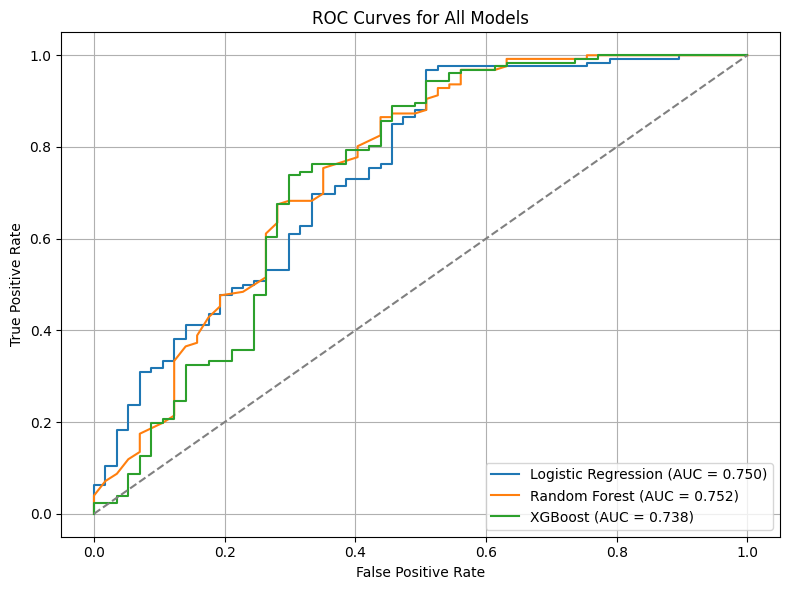

In [205]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Словарь для хранения кривых
roc_data = {}

# Повторно вычисляем fpr, tpr и auc для каждой модели
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]  # Получаем вероятности для класса 1
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

# Визуализация
plt.figure(figsize=(8, 6))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Диагональ
plt.title("ROC Curves for All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

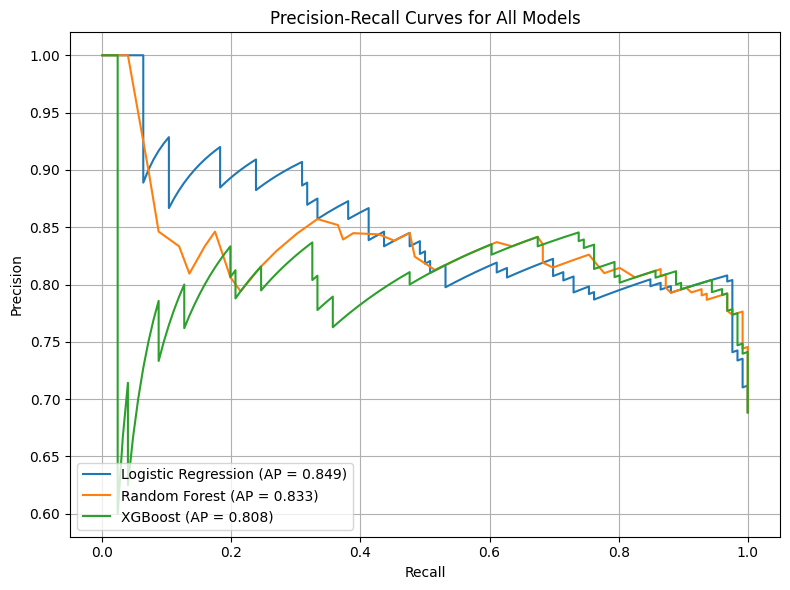

In [206]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Словарь для хранения данных PR-кривой
pr_data = {}

# Вычисляем для каждой модели precision, recall и average precision
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]  # вероятность класса 1
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    avg_precision = average_precision_score(y_test, y_proba)
    pr_data[name] = (precision, recall, avg_precision)

# Визуализация
plt.figure(figsize=(8, 6))

for name, (precision, recall, avg_precision) in pr_data.items():
    plt.plot(recall, precision, label=f"{name} (AP = {avg_precision:.3f})")

plt.title("Precision-Recall Curves for All Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()